In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
    print(f.keys())

    R = f["R3"]
    print(R.keys())
    print(R["wall"].keys())
    print(R["wall"]["tau_mean_a"])
    print(f["R3"]["t"][:5])
    print(f["R13"]["t"][:5])
    print(f["R13"]["t"].shape)
    print(f["R13"]["t"][-1])
    print(f["R3"]["t"][-1])

<KeysViewHDF5 ['R13', 'R14', 'R15', 'R18', 'R19', 'R21', 'R22', 'R23', 'R26', 'R28', 'R3', 'R4', 'R5', 'Ubase_laminar', 'Ubase_periodic_mean', 'readme', 'x', 'y', 'z']>
<KeysViewHDF5 ['is_turbulent', 'p_rapid', 'p_slow', 'p_stokes', 'p_total', 't', 'u', 'v', 'w', 'wall']>
<KeysViewHDF5 ['dudy_a', 'dudy_b', 'dwdy_a', 'dwdy_b', 'p_rapid_a', 'p_rapid_b', 'p_slow_a', 'p_slow_b', 'p_stokes_a', 'p_stokes_b', 'p_total_a', 'p_total_b', 'tau_mean_a', 'tau_mean_b']>
<HDF5 dataset "tau_mean_a": shape (4801,), type "<f4">
[200. 201. 202. 203. 204.]
[208. 224. 240. 256. 272.]
(300,)
4992.0
5000.0


In [2]:
keys = 'u', 'v', 'w', 'p_total'

def extract(reals, keys):
    
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for real in reals:
            data = []
            for k in keys:
                data.append(np.array(f[real][k]))
            yield np.stack(data, axis=1)

        

In [3]:
realizations = ['R13', 'R14', 'R15', 'R18', 'R19', 'R21', 'R22', 'R23', 'R26', 'R28', 'R3', 'R4', 'R5']
raw_d = list(extract(realizations, keys))

In [4]:
all_data = np.concatenate(raw_d, axis=0)

In [5]:
all_data.shape

(17403, 4, 24, 33, 24)

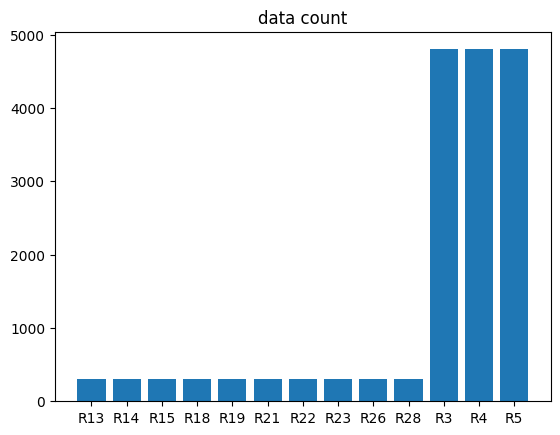

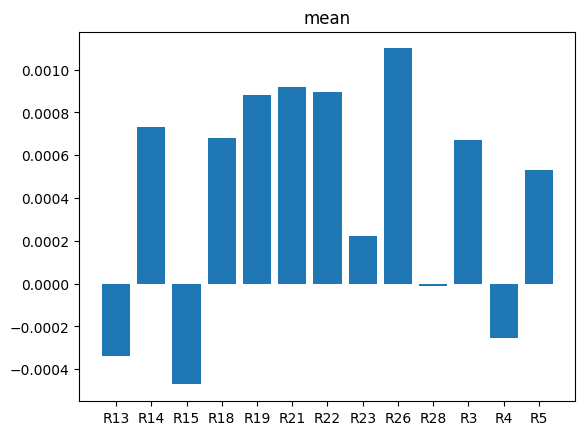

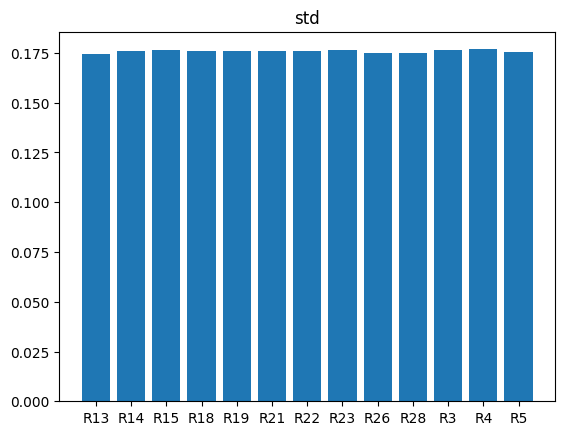

In [6]:
plt.bar(realizations, [d.shape[0] for d in raw_d])
plt.title("data count")
plt.show()
plt.bar(realizations, [d.mean() for d in raw_d])
plt.title("mean")
plt.show()
plt.bar(realizations, [d.std() for d in raw_d])
plt.title("std")
plt.show()

In [7]:
print(all_data.mean())
print(all_data.std())

0.0003402244
0.17617169


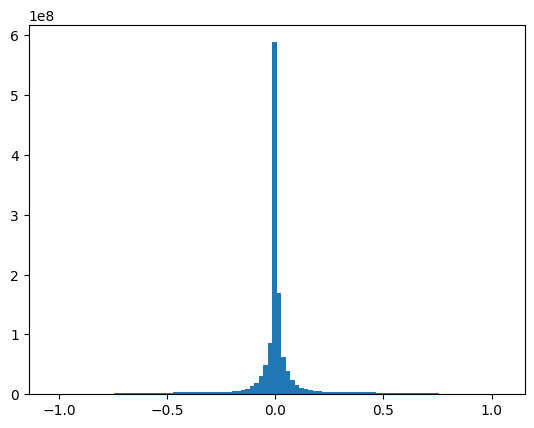

In [8]:
plt.hist(all_data.flatten(), bins=100)
plt.show()